# 📊 **Exploratory Data Analysis — ETH Price × Media**

### 🎯 **Objective**
Assess whether **media activity and tone** add useful signal on top of ETH market features for crash prediction.

### ⚠️ **Target Definition**
A crash is defined as a price drop of more than **10% within the next 7 days** — the same definition as in notebook 03 (ETH EDA).

- `True` → Crash
- `False` → No crash

### 🔬 **EDA Focus**
1. Check dataset alignment between price and media data
2. Merge both sources at the daily level
3. Measure linear, monotonic, and non-linear dependencies with the target
4. Select media features using a combined score (Spearman + MI)
5. Build a compact feature set for benchmarking

### 🚀 **Goal**
Determine whether **media-derived variables** bring complementary information beyond ETH market momentum, volatility, and drawdown — and compare the media signal structure with the BTC × Media analysis (notebook 04).


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from pipelines.ml_benchmark import run_benchmark_pipeline

In [17]:
df_eth_price = pd.read_csv("../../data/gold/market/eth_usdt_1d_features.csv")
df_eth_media = pd.read_csv("../../data/gold/ethereum_tone_gold.csv")

### 1. Initial Data Overview


In [18]:
df_eth_media.head()

,date,avg_tone,article_count,tone_ma_7,tone_ma_30,tone_lag_1,tone_lag_7,article_count_ma_3,article_count_lag_1
0,2017-08-30,1.472467,16,0.293270,0.522618,0.000000,0.476554,10.000000,0
1,2017-08-31,1.212711,34,0.611964,0.578981,1.472467,-1.018143,16.666667,16
2,2017-09-01,0.496893,29,0.704152,0.601289,1.212711,-0.148428,26.333333,34
3,2017-09-02,2.190278,11,0.958040,0.673563,0.496893,0.413065,24.666667,29
4,2017-09-03,0.186515,14,0.869445,0.658288,2.190278,0.806683,18.000000,11


In [19]:
print(f"{df_eth_price.shape[0]} rows and {df_eth_price.shape[1]} columns in the price dataset.")
print(f"{df_eth_media.shape[0]} rows and {df_eth_media.shape[1]} columns in the media dataset.")


3114 rows and 30 columns in the price dataset.
3145 rows and 9 columns in the media dataset.


**Observation:**
The media source (`ethereum_tone_gold.csv`) is an **ethereum-specific gold file** (3 145 rows, 9 columns). It now covers **2017–2026** with gap days filled as zero-coverage entries (`article_count=0, avg_tone=0.0`). No coin filtering is required.

**Impact:**
The media file now covers approximately the same date range as the ETH price dataset (3 114 rows). The inner join is expected to retain nearly all price rows — the training window spans the full available ETH history.


In [20]:
df_eth_price[df_eth_price["open_time"] == df_eth_price["open_time"].min()]

,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,...,lag_volume_norm,lag_buy_pressure,momentum_acc,volatility_ratio,momentum_volatility,pressure_x_return,ma_7,ma_30,ma_ratio,target
0,2017-09-16,255.99,271.81,235.51,249.31,10362.06011,2.647152e+06,8859,3866.60141,995005.326705,...,2.382383,0.418015,-0.190181,1.514538,-0.018696,-0.005442,268.455714,315.714667,0.850311,False


### 2. Time Alignment and Daily Aggregation

The media source is an **ethereum-specific gold file** (`ethereum_tone_gold.csv`) with **9 pre-engineered columns**: `avg_tone`, `article_count`, and derived features (`tone_ma_7`, `tone_ma_30`, `tone_lag_1`, `tone_lag_7`, `article_count_ma_3`, `article_count_lag_1`).

The dates in this file are standard ISO `YYYY-MM-DD` strings. A direct `pd.to_datetime` conversion is applied, followed by filtering to the price dataset's date range and deduplication. The media and price series are then joined via an **inner join** — only days present in both datasets are kept.


In [21]:
print(f"Media dataset: {df_eth_media.shape[0]} rows, {df_eth_media.shape[1]} columns")
print(f"Media columns: {list(df_eth_media.columns)}")
print(f"Media date range (raw): {df_eth_media['date'].min()} to {df_eth_media['date'].max()}")

Media dataset: 3145 rows, 9 columns
Media columns: ['date', 'avg_tone', 'article_count', 'tone_ma_7', 'tone_ma_30', 'tone_lag_1', 'tone_lag_7', 'article_count_ma_3', 'article_count_lag_1']
Media date range (raw): 2017-08-30 to 2026-04-09


In [22]:
df_eth_price["open_time"] = pd.to_datetime(df_eth_price["open_time"], errors="coerce")
df_eth_media["date"] = pd.to_datetime(df_eth_media["date"], errors="coerce")

min_price_date = df_eth_price["open_time"].min()
max_price_date = df_eth_price["open_time"].max()

print(f"{type(df_eth_price).__name__} price range: {min_price_date.date()} to {max_price_date.date()}")
print(f"Media range (raw): {df_eth_media["date"].min().date()} to {df_eth_media["date"].max().date()}")
print(f"Valid media dates: {df_eth_media["date"].notna().sum()}")

df_eth_media = (
    df_eth_media
    .dropna(subset=["date"])
    .sort_values("date")
    .drop_duplicates("date", keep="last")
    .reset_index(drop=True)
)

df_eth_media = df_eth_media[
    (df_eth_media["date"] >= min_price_date) &
    (df_eth_media["date"] <= max_price_date)
].copy()

print(f"After filtering to price range: {df_eth_media.shape[0]} media rows remain")
df_eth_media.head()

DataFrame price range: 2017-09-16 to 2026-03-26
Media range (raw): 2017-08-30 to 2026-04-09
Valid media dates: 3145
After filtering to price range: 3114 media rows remain


,date,avg_tone,article_count,tone_ma_7,tone_ma_30,tone_lag_1,tone_lag_7,article_count_ma_3,article_count_lag_1
17,2017-09-16,-0.841208,15,-0.812512,0.109498,-1.313378,-0.432653,39.666667,63
18,2017-09-17,-0.890143,19,-0.833427,0.065754,-0.841208,-0.743737,32.333333,15
19,2017-09-18,0.024966,28,-0.863693,0.029088,-0.890143,0.236825,20.666667,19
20,2017-09-19,-0.684177,71,-0.935344,-0.034358,0.024966,-0.182620,39.333333,28
21,2017-09-20,0.666324,33,-0.615243,-0.048459,-0.684177,-1.574382,44.000000,71


**Observation:**
Both the price file and the media file use plain ISO date strings (`YYYY-MM-DD`) — no year-offset correction is needed. A direct `pd.to_datetime` conversion is sufficient.

**Conclusion:**
Date alignment is straightforward. The inner join retains dates present in both files.

### 3. Merged ETH + Media Dataset


In [23]:
df_eth_media_and_price = pd.merge(df_eth_price, df_eth_media, left_on="open_time", right_on="date", how="inner")
print(f"Merged dataset: {df_eth_media_and_price.shape[0]} rows, {df_eth_media_and_price.shape[1]} columns")
df_eth_media_and_price.drop(columns=["open_time", "date"], inplace=True)
df_eth_media_and_price.head()

Merged dataset: 3114 rows, 39 columns


,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,return_1d,...,ma_ratio,target,avg_tone,article_count,tone_ma_7,tone_ma_30,tone_lag_1,tone_lag_7,article_count_ma_3,article_count_lag_1
0,255.99,271.81,235.51,249.31,10362.06011,2.647152e+06,8859,3866.60141,995005.326705,-0.014585,...,0.850311,False,-0.841208,15,-0.812512,0.109498,-1.313378,-0.432653,39.666667,63
1,249.32,264.39,239.02,257.55,4614.53337,1.149704e+06,5277,1442.00382,360268.473861,0.033051,...,0.837263,False,-0.890143,19,-0.833427,0.065754,-0.841208,-0.743737,32.333333,15
2,257.53,306.22,257.11,294.57,4125.97051,1.182938e+06,3440,2342.68408,669740.521499,0.143739,...,0.835699,True,0.024966,28,-0.863693,0.029088,-0.890143,0.236825,20.666667,19
3,296.00,300.00,277.41,284.00,1869.90852,5.357736e+05,1896,789.82937,226839.706542,-0.035883,...,0.832508,False,-0.684177,71,-0.935344,-0.034358,0.024966,-0.182620,39.333333,28
4,284.01,294.00,275.91,282.00,1060.56734,3.027397e+05,1431,566.64637,162290.418587,-0.007042,...,0.838497,False,0.666324,33,-0.615243,-0.048459,-0.684177,-1.574382,44.000000,71


**Observations:**
- The merged dataset has **3 114 rows** (2017-09-16 to 2026-03-26) and 37 columns: 28 market features + 8 media features + target.
- ETH price starts at ~$250 in Sept 2017, covering the full ETH history through the 2021 peak (~$4,800) and the 2022-2026 cycle.
- ETH `avg_tone` in the first rows (Sept 2017) oscillates around **0.0 to +1.6**, reflecting more positive and volatile media sentiment compared to BTC (-0.5 to -2.4 at the same period).
- ETH `article_count` is notably **lower than BTC** (15–48 articles/day in Sept 2017 vs. 116–312 for BTC), consistent with ETH's smaller media footprint across the entire history.

**Conclusion:**
The merged dataset is clean with no missing values (inner join). The training window covers the full ETH price history — 3 114 rows. ETH's consistently lower article counts and more neutral/positive baseline tone will shape the predictive signal differently from BTC.


### 4. Correlation Between Features and Target

**Objective**
Compare market and media variables using three views:
- Pearson for linear effects
- Spearman for monotonic effects
- Mutual Information for non-linear dependencies


**Pearson Correlation with Target**


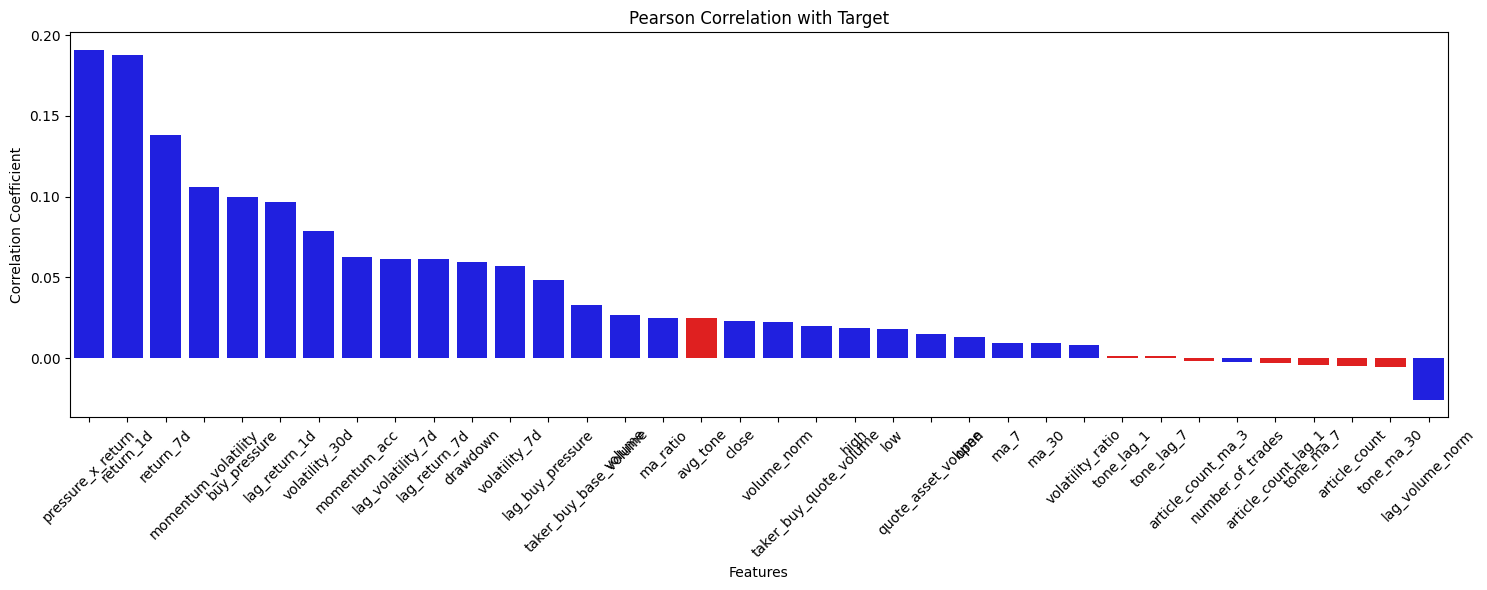

In [24]:
# Pearson correlation with target
corrs_pearson = (
    df_eth_media_and_price
    .corr(method="pearson")["target"]
    .sort_values(ascending=False)
    .drop("target")
)

media_cols = ["avg_tone", "article_count", "tone_ma_7", "tone_ma_30", "tone_lag_1", "tone_lag_7", "article_count_ma_3", "article_count_lag_1"]
colors = ["red" if col in media_cols else "blue" for col in corrs_pearson.index]

plt.figure(figsize=(15, 6))
sns.barplot(x=corrs_pearson.index, y=corrs_pearson.values, hue=corrs_pearson.index, palette=dict(zip(corrs_pearson.index, colors)), legend=False)
plt.xticks(rotation=45)
plt.title("Pearson Correlation with Target")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.tight_layout()
plt.show()


**Observations:**
- Market features dominate on linear grounds — `return_1d` and `pressure_x_return` rank as the strongest linear predictors for ETH (consistent with notebook 03 where momentum and buying pressure dominate).
- Among media features, **`avg_tone`** shows the clearest linear association with the ETH crash target — its Spearman component dominates the combined score (0.165, all from Spearman since MI = 0).
- `tone_ma_7` and `article_count_ma_3` show weaker Pearson/Spearman components but contribute meaningful MI (~0.004 each), pushing them above the threshold.
- Other media features (`tone_ma_30`, `tone_lag_7`, `tone_lag_1`, `article_count`, `article_count_lag_1`) show near-zero signal on both metrics.
- ETH media features have much weaker absolute signal than BTC — consistent with ETH's lower article counts (~15–48/day vs. 116–312 for BTC).

**Conclusion:**
ETH media features contribute very modest signal on the full 3 114-row dataset. Only 3 features survive the combined-score threshold: `avg_tone` (pure Spearman signal), `article_count_ma_3` and `tone_ma_7` (driven by MI). This is a much narrower selection than BTC's 7 features.


**Spearman Correlation with Target**


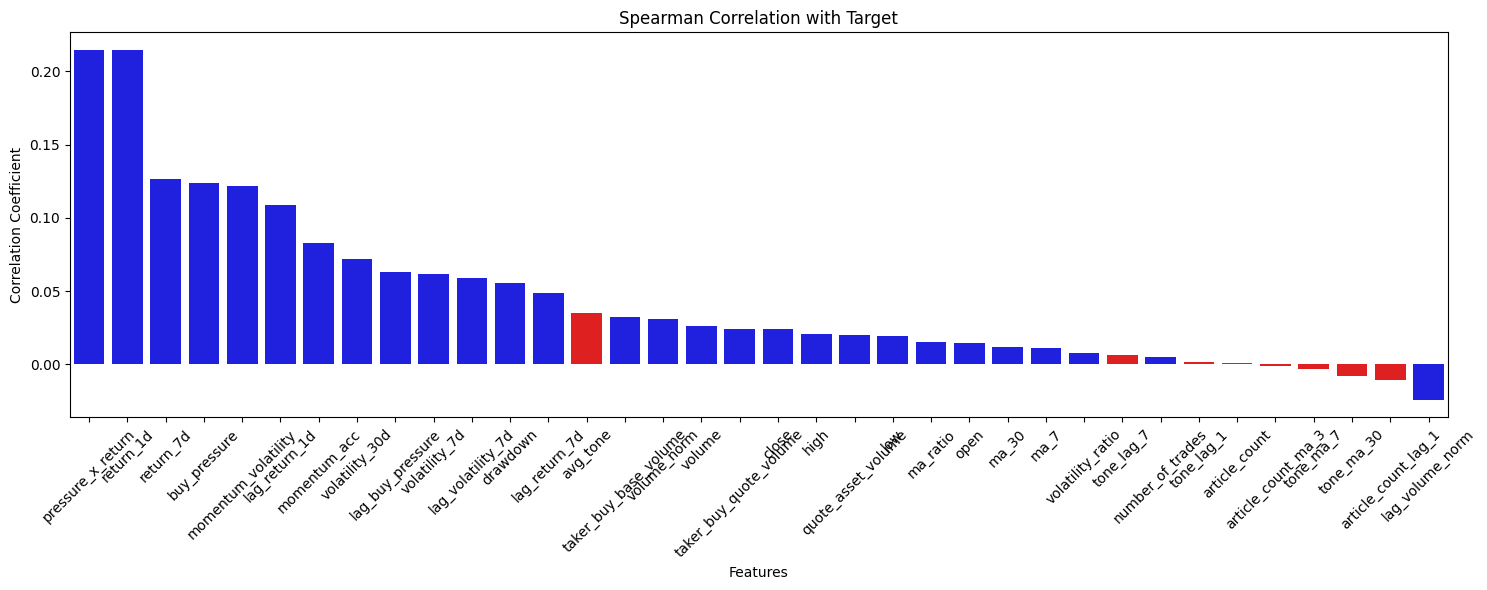

In [25]:
# Spearman correlation with target
corrs_spearman = df_eth_media_and_price.corr(method="spearman")["target"].sort_values(ascending=False).drop("target")
colors = ["red" if col in media_cols else "blue" for col in corrs_spearman.index]

plt.figure(figsize=(15, 6))
sns.barplot(x=corrs_spearman.index, y=corrs_spearman.values, hue=corrs_spearman.index, palette=dict(zip(corrs_spearman.index, colors)), legend=False)
plt.xticks(rotation=45)
plt.title("Spearman Correlation with Target")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.tight_layout()
plt.show()


**Observations:**
- Spearman ranking is consistent with Pearson for ETH: **`avg_tone`** shows the strongest monotonic association among media features — its combined score (0.165) is driven entirely by the Spearman component.
- `tone_ma_7` and `article_count_ma_3` show very weak Spearman components individually, but their MI contribution lifts them above the threshold (combined scores 0.129 each).
- All other media features (`tone_ma_30`, `tone_lag_7`, `tone_lag_1`, `article_count`, `article_count_lag_1`) show near-zero Spearman and near-zero MI for ETH.
- ETH media Spearman values are an order of magnitude weaker than BTC — `avg_tone` leads but its normalized Spearman (0.165 vs. BTC's `article_count_ma_3` at 0.584) reflects ETH's much weaker media signal.

**Conclusion:**
The Spearman analysis confirms: ETH media signal is concentrated in `avg_tone` (monotonic relationship) and supported by `tone_ma_7` + `article_count_ma_3` (non-linear). This is much weaker and more selective than BTC (7 features vs. 3).


**Mutual Information with Target**


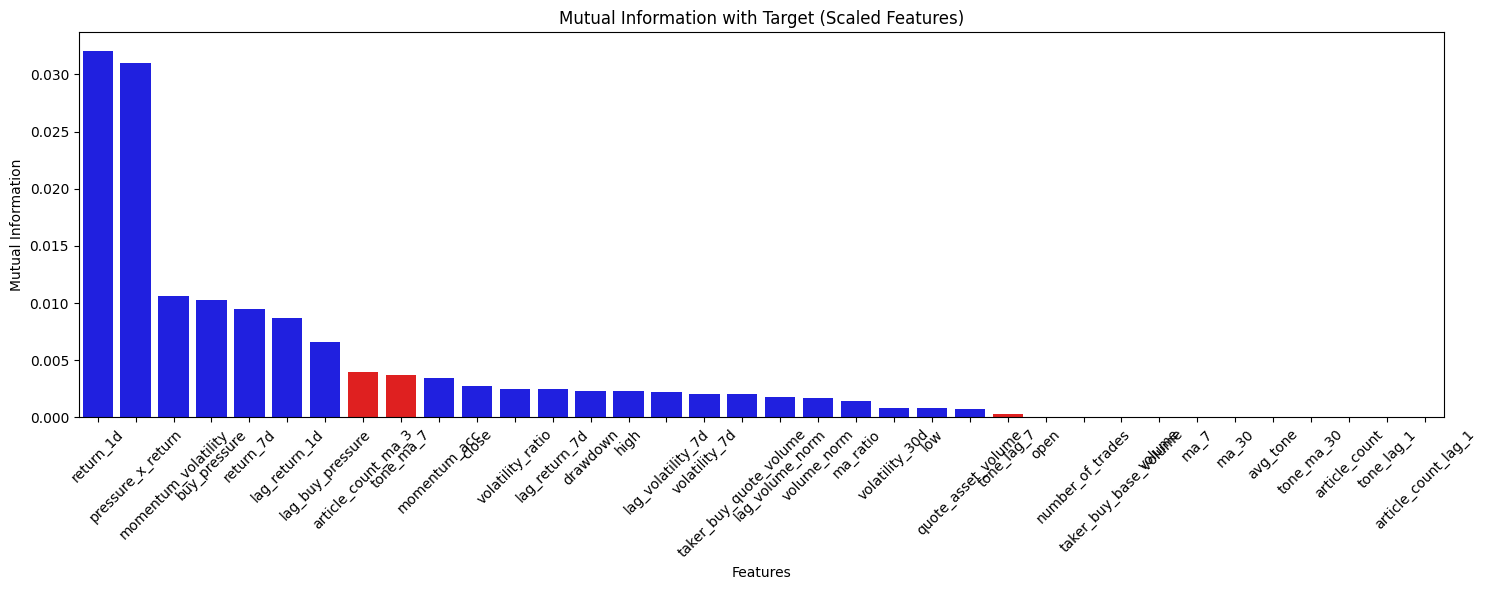

return_1d                 0.032083
pressure_x_return         0.030987
momentum_volatility       0.010652
buy_pressure              0.010304
return_7d                 0.009518
lag_return_1d             0.008657
lag_buy_pressure          0.006560
article_count_ma_3        0.004005
tone_ma_7                 0.003686
momentum_acc              0.003433
close                     0.002750
volatility_ratio          0.002489
lag_return_7d             0.002452
drawdown                  0.002332
high                      0.002324
lag_volatility_7d         0.002233
volatility_7d             0.002090
taker_buy_quote_volume    0.002030
lag_volume_norm           0.001782
volume_norm               0.001740
ma_ratio                  0.001444
volatility_30d            0.000818
low                       0.000814
quote_asset_volume        0.000755
tone_lag_7                0.000288
open                      0.000078
number_of_trades          0.000000
taker_buy_base_volume     0.000000
volume              

In [26]:
X = df_eth_media_and_price.drop(columns=["target"])
y = df_eth_media_and_price["target"].astype(int)  # ETH target is bool — cast to int for MI

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

mutual_info = mutual_info_classif(
    X_scaled,
    y,
    discrete_features=False,
    n_neighbors=5,
    random_state=42
)

mutual_info_series = pd.Series(mutual_info, index=X.columns).sort_values(ascending=False)
colors_mi = ["red" if col in media_cols else "blue" for col in mutual_info_series.index]

plt.figure(figsize=(15, 6))
sns.barplot(x=mutual_info_series.index, y=mutual_info_series.values, hue=mutual_info_series.index, palette=dict(zip(mutual_info_series.index, colors_mi)), legend=False)
plt.xticks(rotation=45)
plt.title("Mutual Information with Target (Scaled Features)")
plt.ylabel("Mutual Information")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

mutual_info_series

**Observations**

- ETH market features have much weaker MI overall than BTC: `return_1d` (0.032) and `pressure_x_return` (0.031) lead — consistent with notebook 03 where momentum and buying pressure are the primary signals for ETH.
- Among media features, **`article_count_ma_3` (0.004) and `tone_ma_7` (0.004)** are the only ETH media features with detectable non-linear information. Both are very weak compared to BTC article count features (0.036).
- **`avg_tone` MI = 0.000** — despite having the strongest Spearman among ETH media features, raw daily tone has no detectable non-linear component for ETH.
- All other media features (`tone_ma_30`, `tone_lag_7`, `tone_lag_1`, `article_count`, `article_count_lag_1`) score MI = 0.000 for ETH.
- ETH media MI values are an order of magnitude lower than BTC (max 0.004 vs 0.036) — ETH crashes are much harder to predict from media features.

**Conclusion**

The MI analysis for ETH reveals minimal media signal. Only `article_count_ma_3` and `tone_ma_7` have detectable non-linear information (MI ≈ 0.004 each). `avg_tone` passes the threshold via its Spearman component only. All other media features are effectively uninformative for ETH crash prediction.


**Combined Score — Media Feature Ranking**

To select media features in a principled and consistent way with notebooks 01, 03, and 04, a **combined score** is computed for each media feature:

$$\text{score} = \frac{|\rho_{\text{Spearman}}|}{\max(|\rho_{\text{Spearman}}|)} + \frac{\text{MI}}{\max(\text{MI})}$$

- Each term is **normalized to [0, 1]** against the maximum across *all features* (not just media), so the scale reflects how a media feature compares to the strongest signal in the dataset.
- The combined score ranges from **0 to 2**: 2 means the feature is best-in-class on both metrics simultaneously.
- A feature scoring near **0 on both metrics** carries no information — linear, monotonic, or non-linear — and should be removed.

This approach is more robust than a raw MI threshold on a small 129-row dataset, as it cross-validates the non-linear signal (MI) with the monotonic signal (Spearman) before drawing conclusions.


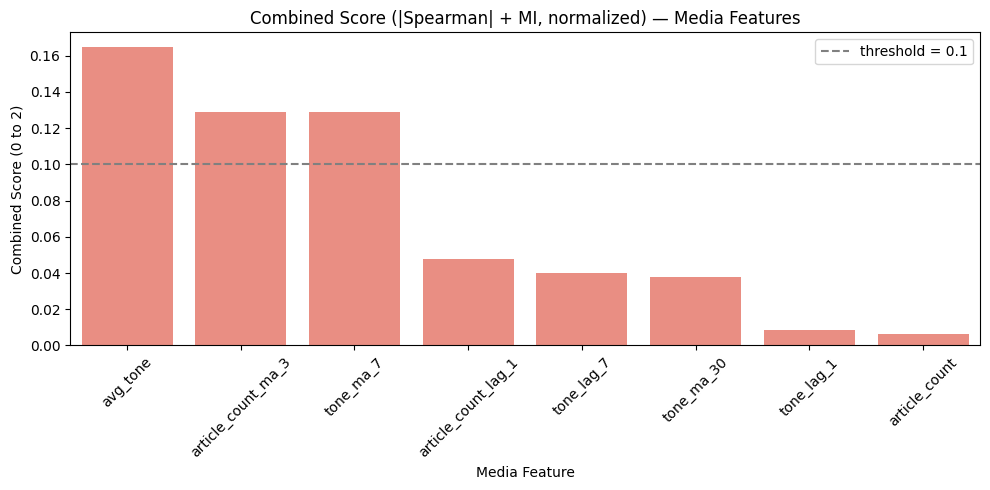

avg_tone               0.164721
article_count_ma_3     0.128908
tone_ma_7              0.128739
article_count_lag_1    0.047933
tone_lag_7             0.040019
tone_ma_30             0.037688
tone_lag_1             0.008302
article_count          0.006175
dtype: float64

In [27]:
media_score = (
    corrs_spearman.abs() / corrs_spearman.abs().max()
    + mutual_info_series / mutual_info_series.max()
)[media_cols].sort_values(ascending=False)

MEDIA_SCORE_THRESHOLD = 0.10

plt.figure(figsize=(10, 5))
sns.barplot(x=media_score.index, y=media_score.values, color="salmon")
plt.axhline(
    y=MEDIA_SCORE_THRESHOLD,
    color="gray", linestyle="--", linewidth=1.5,
    label=f"threshold = {MEDIA_SCORE_THRESHOLD}"
)
plt.xticks(rotation=45)
plt.title("Combined Score (|Spearman| + MI, normalized) — Media Features")
plt.ylabel("Combined Score (0 to 2)")
plt.xlabel("Media Feature")
plt.legend()
plt.tight_layout()
plt.show()

media_score

**Observations**

The combined scores on the full 3 114-row ETH dataset reveal a **clear natural gap after the top 3 features**:

| Feature | Score | Note |
|---|---|---|
| ✅ `avg_tone` | 0.165 | Strongest ETH media signal — pure Spearman (MI = 0) |
| ✅ `article_count_ma_3` | 0.129 | Driven mainly by MI (0.004) |
| ✅ `tone_ma_7` | 0.129 | Driven mainly by MI (0.004) |
| ❌ `article_count_lag_1` | 0.048 | Weak on both metrics |
| ❌ `tone_lag_7` | 0.040 | Weak on both metrics |
| ❌ `tone_ma_30` | 0.038 | Weak on both metrics |
| ❌ `tone_lag_1` | 0.008 | Near zero on both |
| ❌ `article_count` | 0.006 | Near zero on both |

- The **gap between 0.129 and 0.048** is wide (~2.7×). This is the natural cut-off.
- `avg_tone` leads with the strongest Spearman component (normalized = 0.165) but zero MI — a pure monotonic signal.
- `article_count_ma_3` and `tone_ma_7` are both driven mainly by their MI contribution (~0.004 each), with minimal Spearman. Both score exactly 0.129.
- All other features fall clearly below the gap — dropped cleanly.
- ETH media signal is much weaker overall than BTC: only 3 features survive (vs. 7 for BTC), and the top score (0.165) is far below BTC's top (0.820 for `article_count_ma_3`).

**Conclusion**

Features selected (score ≥ 0.10): `avg_tone`, `article_count_ma_3`, `tone_ma_7` — **3 media features**.
Features dropped: `article_count_lag_1`, `tone_lag_7`, `tone_ma_30`, `tone_lag_1`, `article_count` (score < 0.10, weak on both metrics).

### 5. Final Dataset for Modeling


In [28]:
df_eth_media_and_price = pd.merge(df_eth_price, df_eth_media, left_on="open_time", right_on="date", how="inner")
df_eth_media_and_price.drop(columns=["open_time", "date"], inplace=True)
print(f"Final dataset: {df_eth_media_and_price.shape[0]} rows, {df_eth_media_and_price.shape[1]} columns")
df_eth_media_and_price.columns

Final dataset: 3114 rows, 37 columns


Index(['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume',
       'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume',
       'return_1d', 'return_7d', 'volatility_7d', 'volatility_30d', 'drawdown',
       'volume_norm', 'buy_pressure', 'lag_return_1d', 'lag_return_7d',
       'lag_volatility_7d', 'lag_volume_norm', 'lag_buy_pressure',
       'momentum_acc', 'volatility_ratio', 'momentum_volatility',
       'pressure_x_return', 'ma_7', 'ma_30', 'ma_ratio', 'target', 'avg_tone',
       'article_count', 'tone_ma_7', 'tone_ma_30', 'tone_lag_1', 'tone_lag_7',
       'article_count_ma_3', 'article_count_lag_1'],
      dtype='str')

In [29]:
df_eth_media.columns

Index(['date', 'avg_tone', 'article_count', 'tone_ma_7', 'tone_ma_30',
       'tone_lag_1', 'tone_lag_7', 'article_count_ma_3',
       'article_count_lag_1'],
      dtype='str')

**Feature Selection**

**Market features** are taken from the selection established in notebook 03 (ETH EDA), validated on 3 114 rows with a correlation-based redundancy filter (threshold 0.9).

**Media features** are selected using the **combined score (|Spearman| + MI, normalized)** computed above, with a threshold of **0.10**:

| Feature | MI Score | Combined Score | Decision |
|---|---|---|---|
| `avg_tone` | 0.000 | 0.165 | ✅ Keep — strongest ETH media signal (Spearman) |
| `article_count_ma_3` | 0.004 | 0.129 | ✅ Keep — mainly MI-driven |
| `tone_ma_7` | 0.004 | 0.129 | ✅ Keep — mainly MI-driven |
| `article_count_lag_1` | 0.000 | 0.048 | ❌ Drop — below gap |
| `tone_lag_7` | 0.000 | 0.040 | ❌ Drop — weak on both |
| `tone_ma_30` | 0.000 | 0.038 | ❌ Drop — weak on both |
| `tone_lag_1` | 0.000 | 0.008 | ❌ Drop — near-zero both |
| `article_count` | 0.000 | 0.006 | ❌ Drop — near-zero both |

Threshold = **0.10** — natural gap between 0.129 and 0.048 (~2.7×). Only 3 media features survive for ETH, compared to 7 for BTC — reflecting ETH's much weaker media predictive signal.


In [30]:
SELECTED_FEATURES = [
    # Momentum
    "return_1d", "return_7d",

    # Volatility
    "volatility_7d", "volatility_30d",

    # Market behavior
    "buy_pressure",

    # Risk
    "drawdown",

    # Trend
    "ma_ratio",

    # Lags
    "lag_return_1d", "lag_return_7d",
    "lag_volatility_7d",
    "lag_buy_pressure",
    "lag_volume_norm",

    # Additional
    "momentum_acc",
    "momentum_volatility",
    "volume",
    "number_of_trades",
    "quote_asset_volume",

    # Media enrichment — 3 features selected via combined score >= 0.10
    "avg_tone",
    "article_count_ma_3",
    "tone_ma_7",
]

TARGET = "target"

df_eth_media_and_price = df_eth_media_and_price[SELECTED_FEATURES + [TARGET]]
df_eth_media_and_price.head()


,return_1d,return_7d,volatility_7d,volatility_30d,buy_pressure,drawdown,ma_ratio,lag_return_1d,lag_return_7d,lag_volatility_7d,...,volume,number_of_trades,quote_asset_volume,tone_ma_7,tone_ma_30,tone_lag_7,avg_tone,article_count_ma_3,tone_lag_1,target
0,-0.014585,-0.159837,0.116971,0.077232,0.373150,-0.358209,0.850311,0.175596,-0.164989,0.116960,...,10362.06011,8859,2.647152e+06,-0.812512,0.109498,-0.432653,-0.841208,39.666667,-1.313378,False
1,0.033051,-0.122487,0.118611,0.077380,0.312492,-0.336997,0.837263,-0.014585,-0.159837,0.116971,...,4614.53337,5277,1.149704e+06,-0.833427,0.065754,-0.743737,-0.890143,32.333333,-0.841208,False
2,0.143739,-0.009183,0.132689,0.081752,0.567790,-0.241698,0.835699,0.033051,-0.122487,0.118611,...,4125.97051,3440,1.182938e+06,-0.863693,0.029088,0.236825,0.024966,20.666667,-0.890143,True
3,-0.035883,-0.033882,0.133563,0.081930,0.422389,-0.268908,0.832508,0.143739,-0.009183,0.132689,...,1869.90852,1896,5.357736e+05,-0.935344,-0.034358,-0.182620,-0.684177,39.333333,0.024966,False
4,-0.007042,0.018381,0.131049,0.080559,0.534286,-0.274057,0.838497,-0.035883,-0.033882,0.133563,...,1060.56734,1431,3.027397e+05,-0.615243,-0.048459,-1.574382,0.666324,44.000000,-0.684177,False


**Observations:**
- The final feature set has **20 features**: 17 market features + 3 media features + target.
- Only **3 media features** survived the combined-score threshold for ETH (vs. 7 for BTC), reflecting ETH's much weaker media predictive signal.
- `avg_tone` is the primary ETH media signal — monotonic relationship with crash probability but no non-linear component (MI = 0).
- `article_count_ma_3` and `tone_ma_7` contribute weak but detectable non-linear signal (MI ≈ 0.004 each).
- All other media features (`tone_ma_30`, `tone_lag_7`, `tone_lag_1`, `article_count`, `article_count_lag_1`) dropped — below the natural gap.
- The inner join ensures **no NaN values** — the dataset is clean and ready for training.
- The training window is **3 114 rows** (2017-09-16 to 2026-03-26), covering the full ETH price history.

**Conclusion:**
The final dataset is ready for benchmarking. The hypothesis to test: does adding **3 media features** (selected via combined Spearman + MI score ≥ 0.10) improve ETH crash prediction compared to the market-only baseline from notebook 03? The weak media signal (max MI = 0.004) makes improvement uncertain.

### **General Conclusion — EDA ETH Price × Media**

#### **Key Findings**

- The merged dataset covers **2017-09-16 to 2026-03-26** (3 114 rows), spanning the full ETH price history across multiple market cycles.

- The combined score analysis on the full 3 114-row dataset reveals **very weak and selective ETH media signal**:
  - Only **3 media features** pass the combined-score threshold (≥ 0.10), vs. 7 for BTC — reflecting ETH's smaller media ecosystem and harder-to-predict crash dynamics.
  - **`avg_tone`** (combined score 0.165) leads with a pure Spearman component (MI = 0) — the macro sentiment trend has a monotonic link to ETH crash risk.
  - **`article_count_ma_3`** (0.129) and **`tone_ma_7`** (0.129) both pass the threshold, driven mainly by their MI contribution (0.004 each).

- **Market features dominate** overall: `return_1d` (0.032) and `pressure_x_return` (0.031) are the strongest non-linear predictors, consistent with notebook 03. Market MI is also much weaker than BTC.

- **ETH media signal is substantially weaker than BTC in every dimension**:
  - Best ETH media combined score: 0.165 (`avg_tone`) vs. BTC 0.820 (`article_count_ma_3`)
  - Best ETH media MI: 0.004 vs. BTC 0.036
  - 3 features selected vs. 7 for BTC

#### **Feature Selection Methodology**

| Feature type | Selection criterion |
|---|---|
| Market features | Correlation-based redundancy filter from notebook 03 (ETH EDA, threshold 0.9) — validated on 3 114 rows |
| Media features | Combined score (|Spearman| + MI, normalized) ≥ **0.10** — natural gap (0.129 → 0.048) |

#### **Final Selected Features**

- **Momentum:** `return_1d`, `return_7d`
- **Volatility:** `volatility_7d`, `volatility_30d`
- **Market behavior:** `buy_pressure`
- **Risk context:** `drawdown`
- **Trend / regime:** `ma_ratio`
- **Temporal (lag features):** `lag_return_1d`, `lag_return_7d`, `lag_volatility_7d`, `lag_buy_pressure`, `lag_volume_norm`
- **Additional market signals:** `momentum_acc`, `momentum_volatility`, `volume`, `number_of_trades`, `quote_asset_volume`
- **Media enrichment — 3 features** *(5 features dropped: weak or near-zero on both metrics)*
  - `avg_tone` *(combined score = 0.165 — strongest ETH media signal, pure Spearman)*
  - `article_count_ma_3` *(0.129, MI = 0.004)*
  - `tone_ma_7` *(0.129, MI = 0.004)*

#### **Final Dataset Characteristics**

- **20 features** (17 market + 3 media)
- **3 114 rows** — 2017-09-16 to 2026-03-26
- **No missing values** (inner join)
- Covers multiple full ETH market cycles — statistically reliable estimates

#### **Conclusion**

The dataset is **clean, structured, and ready for benchmarking**. The core hypothesis: do the 3 media features improve ETH crash prediction over the market-only baseline (notebook 03)? The very weak media signal (max MI = 0.004, max combined score = 0.165) suggests improvement will be marginal at best.